# Neural Network Regression in PyTorch

## Objective

Build and train a feedforward neural network in PyTorch to solve a supervised regression problem using synthetically generated data.

The dataset should be generated using Scikit-Learn’s regression data generator with the following specifications:

- Number of samples: 5000
- Number of features: 8
- Number of informative features: 6
- Noise level: 15
- Random state: 42



In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as f
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Dataset Preparation

1. Generate a synthetic regression dataset using Scikit-Learn.
2. Perform a:
   - training split
   - validation split
   - test split

3. Convert the resulting NumPy arrays into PyTorch tensors.

Suggested split proportions:

- Training set: 70%
- Validation set: 15%
- Test set: 15%

---

In [ ]:
# Generate synthetic regression dataset
X, y = make_regression(n_samples=5000, n_features=8, n_informative=6, noise=15, random_state=42)

In [ ]:
#Train_Val_Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

In [ ]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_val = torch.tensor(X_val, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_val = torch.tensor(y_val, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [ ]:
y_train = y_train.view(-1, 1)
y_val = y_val.view(-1, 1)
y_test = y_test.view(-1, 1)

In [ ]:
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_val: {X_val.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: torch.Size([3500, 8])
Shape of X_val: torch.Size([750, 8])
Shape of X_test: torch.Size([750, 8])
Shape of y_train: torch.Size([3500, 1])
Shape of y_val: torch.Size([750, 1])
Shape of y_test: torch.Size([750, 1])


### Neural Network Construction

Build a fully connected feedforward neural network with:

- Input layer corresponding to the number of features
- At least two hidden layers
- One output neuron for regression prediction

Recommended architecture:

- Hidden Layer 1: 32 neurons
- Hidden Layer 2: 16 neurons
- Activation Function: ReLU



In [ ]:
class NN_reg(nn.Module):
  def __init__(self,input_size, hidden_size_1, hidden_size_2,output_size):
    super(NN_reg,self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size_1)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size_1, hidden_size_2)
    self.fc3 = nn.Linear(hidden_size_2,output_size)

  def forward(self,x):
    out = self.fc1(x)
    out = self.relu(out)
    out = self.fc2(out)
    out = self.relu(out)
    out = self.fc3(out)
    return out

### Model Training

Train the neural network using:

- Loss Function: Mean Squared Error (MSELoss)
- Optimizer: Adam

During training:

- Track training loss over epochs
- Track validation loss over epochs
- Use the validation set to monitor overfitting
- Evaluate final model performance on the test set

---

In [ ]:
model = NN_reg(input_size=8, hidden_size_1=32, hidden_size_2=16, output_size=1)
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 1000
train_losses = []
val_losses = []

In [ ]:
for epoch in range(epochs):
  model.train()
  y_pred = model(X_train)
  train_loss = loss_func(y_pred, y_train)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  train_losses.append(train_loss.item())

  model.eval()
  with torch.no_grad():
    val_pred = model(X_val)
    val_loss = loss_func(val_pred, y_val)
    val_losses.append(val_loss.item())

    if (epoch + 1) % 100 == 0:
      print(
          f"Epoch [{epoch+1}/1000], "
          f"Train Loss: {train_loss.item():.4f}, "
          f"Val Loss: {val_loss.item():.4f}")

Epoch [100/1000], Train Loss: 383.8057, Val Loss: 426.4579
Epoch [200/1000], Train Loss: 280.3381, Val Loss: 323.2942
Epoch [300/1000], Train Loss: 247.4916, Val Loss: 290.8426
Epoch [400/1000], Train Loss: 227.6245, Val Loss: 270.8391
Epoch [500/1000], Train Loss: 217.5956, Val Loss: 260.4527
Epoch [600/1000], Train Loss: 212.7455, Val Loss: 256.5355
Epoch [700/1000], Train Loss: 209.7369, Val Loss: 253.1096
Epoch [800/1000], Train Loss: 207.7961, Val Loss: 250.8805
Epoch [900/1000], Train Loss: 206.6276, Val Loss: 250.3912
Epoch [1000/1000], Train Loss: 205.7421, Val Loss: 249.3943



## Expected Performance

A correctly implemented model should approximately achieve:

| Metric | Expected Range |
|---|---|
| Validation/Test MSE | 150–500 |
| RMSE | 12–22 |
| \(R^2\) Score | 0.90–0.98 |

A high-performing model should achieve:

\[
R^2 > 0.95
\]


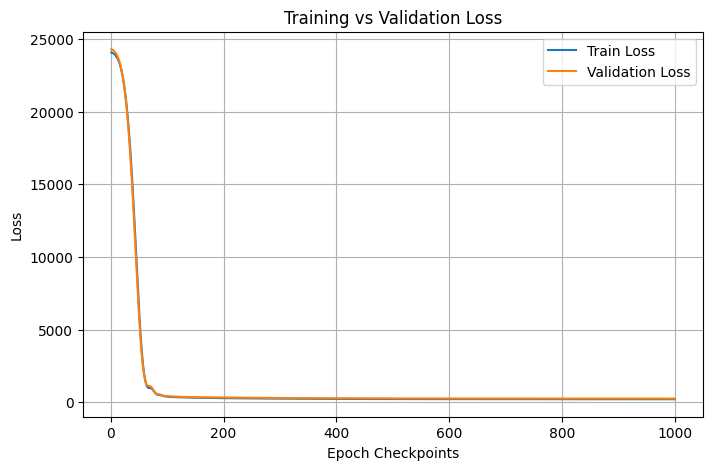

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch Checkpoints")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()
with torch.no_grad():
  y_pred = model(X_test)
  test_loss = loss_func(y_pred,y_test)
  print(f"Test Loss: {test_loss.item():.4f}")

# Convert tensors to NumPy
y_test_np = y_test.numpy()
y_pred_np = y_pred.numpy()

# Metrics
mse = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, y_pred_np)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² Score: {r2:.4f}")

Test Loss: 242.9155
Test MSE: 242.9155
Test RMSE: 15.5857
Test R² Score: 0.9898
